| Collection ID | Band(s) | Spatial Resolution | Temporal Resolution |
|---|---|---|---|
| modis-aqua-myd11a2 | LST_Day_1km | 1 km | 8 days |
| modis-aqua-myd13a1 | 500m 16 days NDVI | 500 m | 16 days |
| modis-terra-mod16a2gf | ET_500m | 500 m | 8 days |
| modis-aqua-myd15a2h | Lai_500m | 500 m | 8 days |
| modis-aqua-myd17a2hgf | Gpp_500m | 500 m | 8 days |

In [8]:
test_aoi = {
  "type": "FeatureCollection",
  "features": [
    {
      "type": "Feature",
      "properties": {},
      "geometry": {
        "type": "Polygon",
        "coordinates": [
          [
            [5.05, 51.21],
            [5.1, 51.21],
            [5.1, 51.23],
            [5.05, 51.23],
            [5.05, 51.21]
          ]
        ]
      }
    }
  ]
}
test_date = ["2024-01-01", "2024-01-31"]

# How do temperature and water availability control ecosystem productivity?


Vegetation productivity doesn't respond to climate in isolation; it is the end product of a chain of physical constraints. Therefore, in this notebook, with the MODIS product using the openEO API, we want to explore the working hypothesis that:

> **Hot year → less moisture → lower ET → lower NDVI → lower GPP**

To test this, we don't look at GPP alone. Instead, we build three complementary lenses on the temperature–water–productivity relationship:

1. **Temperature stress**: Is the land surface running anomalously hot 
   relative to its own seasonal baseline? (LST anomaly)
2. **Water-carbon coupling** How efficiently is the ecosystem trading water loss for carbon gain? (Water Use Efficiency = GPP / ET)
3. **Productivity per unit canopy**: is the vegetation that *is* present 
   photosynthesising efficiently, or is it under-performing for its greenness?: (GPP / NDVI)

Together, these move us from "is it hot?" to "does that heat translate into 
a measurable productivity?"

In [9]:
import openeo

connection = openeo.connect("openeo-staging.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


In [10]:
iberian_peninsula = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {
                "name": "Iberian Peninsula"
            },
            "geometry": {
                "type": "Polygon",
                "coordinates": [
                    [
                        [-10.0, 36.0],
                        [4.5, 36.0],
                        [4.5, 44.5],
                        [-10.0, 44.5],
                        [-10.0, 36.0]
                    ]
                ]
            }
        }
    ]
}

temporal_extent = ["2025-01-01", "2025-12-31"]

In [11]:
def get_stac_cube(collection, bands):
    url = f"https://stac.dataspace.copernicus.eu/v1/collections/{collection}"
    stac_cube = connection.load_stac(url,
                                    temporal_extent=test_date,
                                    spatial_extent=test_aoi,
                                    bands=bands
                                    )
    return stac_cube

We fetch in four MODIS products from the CDSE STAC catalogue to perform the following steps: 
- **LST** (1 km) — temperature 
- **NDVI** (500 m) — vegetation greenness 
- **ET** (500 m) — evapotranspiration, our proxy for water availability/use 
- **GPP** (500 m, from the Carbon Products section) — realized productivity.

In [12]:
lst_collection_id = "modis-aqua-myd11a2"
lst_bands = ["LST_Day_1km"]
lst_cube = get_stac_cube(lst_collection_id, lst_bands)


# ndvi 
ndvi_collection_id = "modis-aqua-myd13a1"     
ndvi_bands = ["500m 16 days NDVI"]
ndvi_cube = get_stac_cube(ndvi_collection_id, ndvi_bands)

#Evapotranspiration
et_collection_id = "modis-terra-mod16a2gf"
et_bands = ["ET_500m"]
et_cube = get_stac_cube(et_collection_id, et_bands)

# lai 
lai_collection_id = "modis-aqua-myd15a2h"
lai_bands = ["Lai_500m"]
lai_cube = get_stac_cube(lai_collection_id, lai_bands)

# gpp
gpp_collection_id = "modis-aqua-myd17a2hgf"
gpp_bands = ["Gpp_500m"]
gpp_cube = get_stac_cube(gpp_collection_id, gpp_bands)

In [13]:
monthly_gpp = gpp_cube.aggregate_temporal_period(
    period="month",
    reducer="mean"
)
monthly_lst = lst_cube.aggregate_temporal_period(
    period="month", 
    reducer="mean"
)
monthly_ndvi = ndvi_cube.aggregate_temporal_period(
    period="month", 
    reducer="mean"
)

### Step 1: Detecting temperature stress. 

The first link in the chain is temperature. Rather than looking at raw land surface temperature (LST), we compute an **anomaly**: the extent to which each month's LST departs from that pixel's annual average.

In [14]:
# calculate lst anomaly
lst_anomaly = lst_cube - monthly_lst

#Are months warmer than the annual average associated with lower productivity?

In [15]:
lst_anomaly

In [8]:
lst_anomaly_mean = lst_anomaly.aggregate_spatial(
    geometries=test_aoi,
    reducer="mean"
)
lst_anomaly_mean.execute_batch(title="LST Anomaly Mean", outputfile="env_prod/lst_anomaly_mean.csv")

0:00:00 Job 'j-26071708233744eea02bbde5a5b9c3cd': send 'start'
0:00:01 Job 'j-26071708233744eea02bbde5a5b9c3cd': created (progress 0%)
0:00:07 Job 'j-26071708233744eea02bbde5a5b9c3cd': queued (progress 0%)
0:00:13 Job 'j-26071708233744eea02bbde5a5b9c3cd': queued (progress 0%)
0:00:21 Job 'j-26071708233744eea02bbde5a5b9c3cd': queued (progress 0%)
0:00:31 Job 'j-26071708233744eea02bbde5a5b9c3cd': running (progress 4.9%)
0:00:44 Job 'j-26071708233744eea02bbde5a5b9c3cd': running (progress 6.7%)
0:00:59 Job 'j-26071708233744eea02bbde5a5b9c3cd': running (progress 8.9%)
0:01:18 Job 'j-26071708233744eea02bbde5a5b9c3cd': running (progress 11.5%)
0:01:42 Job 'j-26071708233744eea02bbde5a5b9c3cd': finished (progress 100%)


<BatchJob job_id='j-26071708233744eea02bbde5a5b9c3cd'>

In [3]:
df

,date,feature_index,LST_Day_1km
0,2024-01-01T00:00:00.000Z,0,5498.484896
1,2024-01-09T00:00:00.000Z,0,13617.821154
2,2024-01-17T00:00:00.000Z,0,13811.660301
3,2024-01-25T00:00:00.000Z,0,14016.371786


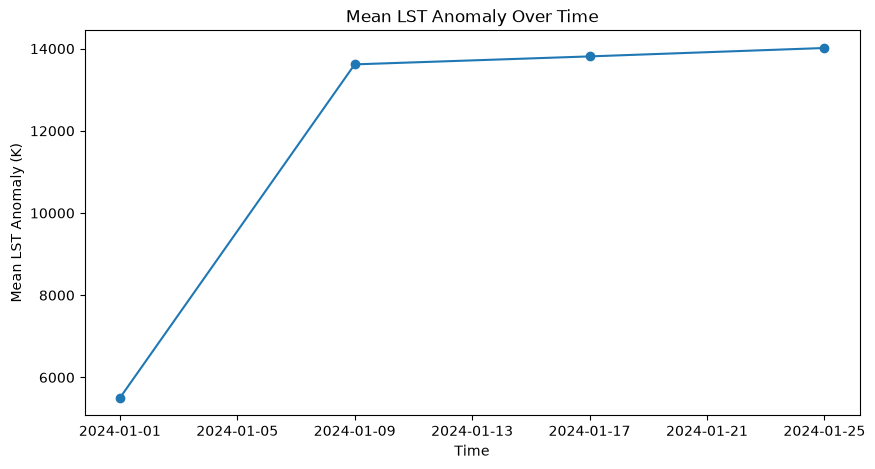

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("env_prod/lst_anomaly_mean.csv")
plt.figure(figsize=(10, 5))
date = pd.to_datetime(df['date'])
plt.plot(date, df['LST_Day_1km'], marker='o')
plt.title('Mean LST Anomaly Over Time')
plt.xlabel('Time')
plt.ylabel('Mean LST Anomaly (K)')
plt.show()


### Step 2: Water Use Efficiency (WUE)  

**Water Use Efficiency (WUE = GPP / ET)** captures this trade-off directly: how much carbon is fixed per unit of water lost. A falling WUE during a hot period is a sign of water-limited stress; in other words, the ecosystem is paying a higher water "cost" for a lower carbon "return."

In [ ]:
# Water Use Efficiency:gives how much carbon is fixed for each unit of water lost?
# wue = gpp_cube / et_cube

merged_gpp_et = gpp_cube.merge_cubes(et_cube)
wue = merged_gpp_et.band("Gpp_500m") / merged_gpp_et.band("ET_500m")

NameError: name 'gpp_cube' is not defined

In [11]:
wue.execute_batch(title="Water Use Efficiency", outputfile="env_prod/wue.nc")

0:00:00 Job 'j-26071708280148748c55880d0d805c8b': send 'start'
0:00:01 Job 'j-26071708280148748c55880d0d805c8b': queued (progress 0%)
0:00:06 Job 'j-26071708280148748c55880d0d805c8b': queued (progress 0%)
0:00:13 Job 'j-26071708280148748c55880d0d805c8b': queued (progress 0%)
0:00:21 Job 'j-26071708280148748c55880d0d805c8b': queued (progress 0%)
0:00:31 Job 'j-26071708280148748c55880d0d805c8b': queued (progress 0%)
0:00:43 Job 'j-26071708280148748c55880d0d805c8b': queued (progress 0%)
0:00:58 Job 'j-26071708280148748c55880d0d805c8b': queued (progress 0%)
0:01:18 Job 'j-26071708280148748c55880d0d805c8b': finished (progress 100%)


<BatchJob job_id='j-26071708280148748c55880d0d805c8b'>

In [ ]:
import matplotlib.pyplot as plt
import xarray as xr

ds = xr.open_dataset("env_prod/wue.nc")


<xarray.Dataset> Size: 3MB
Dimensions:   (t: 4, x: 357, y: 233)
Coordinates:
  * t         (t) datetime64[ns] 32B 2024-01-01 2024-01-09 2024-01-17 2024-01-25
  * x         (x) float64 3kB 6.431e+05 6.431e+05 ... 6.467e+05 6.467e+05
  * y         (y) float64 2kB 5.677e+06 5.677e+06 ... 5.675e+06 5.675e+06
Data variables:
    crs       |S1 1B ...
    Gpp_500m  (t, y, x) float32 1MB ...
    ET_500m   (t, y, x) float32 1MB ...
Attributes:
    Conventions:  CF-1.9
    institution:  Copernicus Data Space Ecosystem openEO API - 0.73.0a16.dev2...
    description:  
    title:

### Step 3: Productivity efficiency (GPP per unit NDVI)  

NDVI tells us how much green canopy is present; GPP tells us how much carbon that canopy is actually fixing. Dividing the two yields a proxy for **photosynthetic efficiency per unit of greenness**; i.e., whether the existing vegetation is performing at full capacity or is "green but struggling". A productivity drop could mean *less vegetation* (falling NDVI) or *the same vegetation working less efficiently* (falling GPP/NDVI). 

In [ ]:
# Productivity Efficiency
# gpp_per_ndvi = monthly_gpp / monthly_ndvi

merged_gpp_ndvi = monthly_gpp.merge_cubes(monthly_ndvi)
gpp_per_ndvi = merged_gpp_ndvi.band("Gpp_500m") / merged_gpp_ndvi.band("500m 16 days NDVI")

In [17]:
job = gpp_per_ndvi.create_job(title="GPP per NDVI")
job.start_and_wait()

0:00:00 Job 'j-260717085717491c8ee51ab692495fa2': send 'start'
0:00:01 Job 'j-260717085717491c8ee51ab692495fa2': created (progress 0%)
0:00:07 Job 'j-260717085717491c8ee51ab692495fa2': queued (progress 0%)
0:00:13 Job 'j-260717085717491c8ee51ab692495fa2': queued (progress 0%)
0:00:21 Job 'j-260717085717491c8ee51ab692495fa2': queued (progress 0%)
0:00:31 Job 'j-260717085717491c8ee51ab692495fa2': queued (progress 0%)
0:00:43 Job 'j-260717085717491c8ee51ab692495fa2': queued (progress 0%)
0:00:59 Job 'j-260717085717491c8ee51ab692495fa2': running (progress 8.8%)
0:01:18 Job 'j-260717085717491c8ee51ab692495fa2': running (progress 11.4%)
0:01:42 Job 'j-260717085717491c8ee51ab692495fa2': running (progress 14.4%)
0:02:12 Job 'j-260717085717491c8ee51ab692495fa2': finished (progress 100%)


<BatchJob job_id='j-260717085717491c8ee51ab692495fa2'>

In [18]:
results = job.get_results()
results.download_files("env_prod/gppperndvi/")

[WindowsPath('env_prod/gppperndvi/openEO_2024-01-01Z.tif'),
 WindowsPath('env_prod/gppperndvi/job-results.json')]

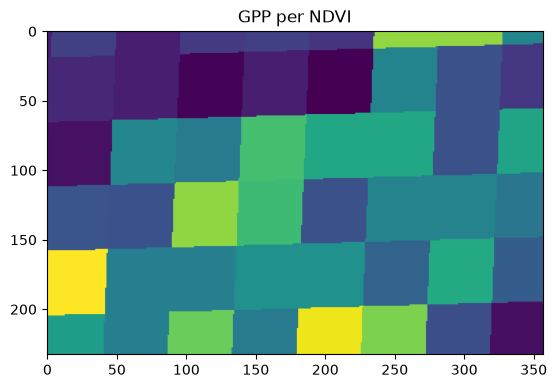

In [5]:
import rasterio 
import matplotlib.pyplot as plt

img = rasterio.open("env_prod/gppperndvi/openEO_2024-01-01Z.tif")
plt.imshow(img.read(1), cmap='viridis')
plt.title("GPP per NDVI")
plt.show()

### Therefore

These three diagnostics let us trace the causal chain rather 
than just correlate temperature with GPP:

| Signal | What it isolates |
|---|---|
| LST anomaly | Is the period unusually hot? |
| WUE (GPP/ET) | Is heat translating into water-limited carbon stress? |
| GPP/NDVI | Is existing vegetation underperforming, or is there simply less of it? |

A hot-year productivity decline that's accompanied by falling WUE **and** 
falling GPP/NDVI is the strongest evidence for the full 
temperature → moisture stress → efficiency loss pathway proposed at the top 
of this section, rather than a coincidental drop driven by land cover change 
or another confounding factor.